In [1]:
import pandas as pd
import json
import xml.etree.ElementTree as ET

In [13]:
# fact.csv
fact = pd.read_csv('dataset/fact.csv')
fact.info()

C:\Users\catta\AppData\Local\Temp\ipykernel_8632\1917879776.py:2: DtypeWarning: Columns (3,11) have mixed types. Specify dtype option on import or set low_memory=False.
  fact = pd.read_csv('dataset/fact.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941649 entries, 0 to 941648
Data columns (total 47 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   match_num           941649 non-null  int64  
 1   winner_id           941649 non-null  int64  
 2   winner_seed         399896 non-null  float64
 3   winner_entry        156231 non-null  object 
 4   winner_name         941649 non-null  object 
 5   winner_hand         922284 non-null  object 
 6   winner_ht           652975 non-null  float64
 7   winner_ioc          941641 non-null  object 
 8   winner_age          929026 non-null  float64
 9   loser_id            941649 non-null  int64  
 10  loser_seed          205049 non-null  float64
 11  loser_entry         277467 non-null  object 
 12  loser_name          941649 non-null  object 
 13  loser_hand          920820 non-null  object 
 14  loser_ht            542290 non-null  float64
 15  loser_ioc           941568 non-nul

In [19]:
fact.head()

,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,...,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,spectator,avg_ticket_price,match_expenses,tourney
0,270,112411,NaN,NaN,Doug Smith,U,NaN,AUS,NaN,110196,...,NaN,NaN,NaN,NaN,NaN,NaN,10006.0,122.32,989177.0,0
1,271,126914,NaN,NaN,Louis Pretorius,R,NaN,RSA,NaN,209536,...,NaN,NaN,NaN,NaN,NaN,NaN,13543.0,174.07,836293.2,0
2,272,209523,NaN,NaN,Cecil Pedlow,U,NaN,IRL,NaN,209535,...,NaN,NaN,NaN,NaN,NaN,NaN,12837.0,142.19,423837.8,0
3,273,100084,NaN,NaN,Tom Okker,R,178.0,NED,24.3,209534,...,NaN,NaN,NaN,NaN,NaN,NaN,9791.0,123.27,881615.0,0
4,274,100132,NaN,NaN,Armistead Neely,R,NaN,USA,21.3,209533,...,NaN,NaN,NaN,NaN,NaN,NaN,12597.0,119.88,919907.6,0


In [16]:
unknown_count = fact[fact['score'] == 'UNK'].shape[0]
print(unknown_count)

96


In [18]:
print(f"\nfact: \n{fact.isnull().sum()[fact.isnull().sum() > 0]}")



fact: 
winner_seed           541753
winner_entry          785418
winner_hand            19365
winner_ht             288674
winner_ioc                 8
winner_age             12623
loser_seed            736600
loser_entry           664182
loser_hand             20829
loser_ht              399359
loser_ioc                 81
loser_age              27027
score                    154
minutes               734503
w_ace                 727479
w_df                  727480
w_svpt                727480
w_1stIn               727480
w_1stWon              727480
w_2ndWon              727480
w_SvGms               727482
w_bpSaved             727480
w_bpFaced             727480
l_ace                 727480
l_df                  727479
l_svpt                727480
l_1stIn               727480
l_1stWon              727480
l_2ndWon              727480
l_SvGms               727482
l_bpSaved             727480
l_bpFaced             727480
winner_rank           108616
winner_rank_points    176914
loser_

In [38]:
fact['winner_ht'].dtype

dtype('float64')

In [37]:
fact['winner_ht'].min()

3.0

In [36]:
fact['loser_ht'].unique()

array([ nan, 188., 183., 185., 179., 190., 175., 173., 180., 178., 191.,
       170., 193., 196., 168., 172., 201., 163., 186., 198., 160., 203.,
       176., 165., 208., 174., 206., 181., 182., 194.,   3., 189., 211.,
        15.,  71., 145., 200., 157., 187., 132.,  13.])

In [4]:
fact['round'].unique()

array(['R32', 'R16', 'QF', 'SF', 'F', 'R64', 'R128', 'RR', 'BR', 'ER',
       'CR', 'PR', 'Q4', 'Q1', 'Q2', 'Q3'], dtype=object)

In [5]:
fact['best_of'].unique()    

array([3, 5, 1], dtype=int64)

In [91]:
fact['winner_hand'].unique()

array(['U', 'R', 'L', nan, 'A'], dtype=object)

In [77]:
tourney = pd.read_csv('dataset/tourney.csv')
tourney.info()

C:\Users\catta\AppData\Local\Temp\ipykernel_9892\2394108477.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  tourney = pd.read_csv('dataset/tourney.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 941649 entries, 0 to 941648
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   tourney            941649 non-null  int64  
 1   tourney_id         941649 non-null  object 
 2   tourney_name       941649 non-null  object 
 3   surface            937020 non-null  object 
 4   draw_size          940814 non-null  object 
 5   tourney_level      941649 non-null  object 
 6   tourney_timestamp  941649 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 50.3+ MB


In [80]:
tourney['tourney_timestamp'].nunique()


5522

In [87]:
tourney['tourney_timestamp']

0        -4.682880e+07
1        -4.682880e+07
2        -4.682880e+07
3        -4.682880e+07
4        -4.682880e+07
              ...     
941644    1.732493e+09
941645    1.732493e+09
941646    1.732493e+09
941647    1.732493e+09
941648    1.732493e+09
Name: tourney_timestamp, Length: 941649, dtype: float64

In [89]:
print(f"\nTourney: \n{tourney.isnull().sum()[tourney.isnull().sum() > 0]}")



Tourney: 
surface      4629
draw_size     835
dtype: int64


In [76]:
countries = pd.read_csv('dataset/countries.csv')
countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  124 non-null    object
 1   country_name  124 non-null    object
 2   continent     124 non-null    object
dtypes: object(3)
memory usage: 3.0+ KB


## Understanding

In [19]:
import pandas as pd

duplicati = fact['winner_rank'][fact['winner_rank'].duplicated()]

conteggio_duplicati = duplicati.value_counts()
valori_ripetuti = conteggio_duplicati[conteggio_duplicati > 1]

print(valori_ripetuti)

winner_rank
1.0       3243
2.0       3101
3.0       2969
4.0       2620
5.0       2579
          ... 
1736.0       2
2053.0       2
2166.0       2
1815.0       2
2106.0       2
Name: count, Length: 2173, dtype: int64


In [20]:
fact['loser_rank_points'].unique()

array([   nan,     0.,    70., ...,  5475., 11180.,  7315.])

In [21]:
fact['score'].unique()

array(['6-1 7-5', '6-1 6-1', '6-2 6-2', ..., '3-2 Def.',
       '6-7(4) 7-6(7) 3-0 RET', '6-0 6-7(6) 6-6 RET'], dtype=object)

In [22]:
fact['winner_rank_points'].unique()

array([  nan,    0.,  591., ..., 7315., 2107., 2089.])

In [23]:
tourney['draw_size'].unique()   

array([32.0, 16.0, 64.0, 128.0, 96.0, 4.0, 8.0, 6.0, nan, 10.0, 5.0, 9.0,
       7.0, 24.0, 48.0, 12.0, 2.0, 56.0, 28.0, '64', '48', '32', '56',
       '128', '8', '4', '96', '28', '16', '24', '12', '2', '18', 'R',
       '29', '31', '23', '30', 30, 23, 21, 22, 29, 31, 25, 17],
      dtype=object)

In [24]:
tourney['tourney_timestamp'].unique()

array([-4.6828800e+07, -3.5942400e+07, -4.5705600e+07, ...,
        1.6725312e+09,  1.6816032e+09,  1.7271360e+09])

In [25]:
fact['winner_ioc'].unique() 

array(['AUS', 'RSA', 'IRL', 'NED', 'USA', 'GBR', 'BRA', 'ESP', 'ARG',
       'UNK', 'CHI', 'CZE', 'JPN', 'DEN', 'CRO', 'HUN', 'FRA', 'GER',
       'COL', 'RUS', 'ROU', 'URS', 'BEL', 'POL', 'UKR', 'ITA', 'SUI',
       'NZL', 'GRE', 'ECU', 'PER', 'IND', 'PHI', 'SRB', 'SWE', 'EGY',
       'MEX', 'JAM', 'CAN', 'INA', 'ZIM', 'VEN', 'BUL', 'FIN', 'POR',
       'SRI', 'IRI', 'ISR', 'MON', 'NOR', 'LUX', 'MAS', 'RHO', 'TUR',
       'CUB', 'PUR', 'PAK', 'BOL', 'AUT', 'TCH', 'SLO', 'FRG', 'YUG', nan,
       'UAE', 'CAR', 'VIE', 'KOR', 'HKG', 'MAR', 'LIB', 'NGR', 'NIG',
       'PAR', 'URU', 'THA', 'ALG', 'BAH', 'TPE', 'CHN', 'SVK', 'BAR',
       'TUN', 'SEN', 'CYP', 'SGP', 'KEN', 'CIV', 'MLT', 'BAN', 'GHA',
       'SYR', 'IRQ', 'DOM', 'BRN', 'CMR', 'KUW', 'JOR', 'CRC', 'HAI',
       'TOG', 'ZAM', 'ECA', 'GUA', 'ESA', 'LAT', 'KSA', 'GEO', 'ARM',
       'EST', 'UZB', 'BLR', 'LTU', 'MKD', 'BIH', 'QAT', 'KAZ', 'MDA',
       'AHO', 'TJK', 'AND', 'SOL', 'SAM', 'MHL', 'OMA', 'MNE', 'GUM',
       'MAD', '

In [26]:
countries['country_code'].unique()

array(['JPN', 'RUS', 'FRA', 'AUS', 'CAN', 'BUL', 'GBR', 'SRB', 'USA',
       'ESP', 'CZE', 'ITA', 'GEO', 'SUI', 'HUN', 'CHI', 'LTU', 'ARG',
       'GER', 'RSA', 'CRO', 'BEL', 'TUN', 'LAT', 'BLR', 'IND', 'POR',
       'NZL', 'GRE', 'SVK', 'AUT', 'KOR', 'ROU', 'MDA', 'URU', 'NED',
       'SLO', 'CYP', 'KAZ', 'TPE', 'UZB', 'BIH', 'UKR', 'POL', 'NOR',
       'BOL', 'BRA', 'COL', 'SWE', 'TUR', 'CHN', 'BAR', 'DOM', 'ECU',
       'FIN', 'GUA', 'MEX', 'PER', 'ESA', 'INA', 'THA', 'PHI', 'DEN',
       'EGY', 'ALG', 'ZIM', 'LUX', 'PAK', 'ISR', 'EST', 'MAR', 'HKG',
       'IRL', 'LIB', 'SRI', 'VEN', 'MNE', 'PAR', 'PNG', 'SIN', 'LIE',
       'GRN', 'BAH', 'CUB', 'TRI', 'OMA', 'MLT', 'MKD', 'KGZ', 'MAS',
       'BDI', 'MRI', 'PUR', 'SAM', 'KEN', 'ARM', 'NAM', 'REU', 'UNK',
       'MON', 'HAI', 'VIE', 'HON', 'PAN', 'CRC', 'SGP', 'TJK', 'POC',
       'IRI', 'PHL', 'MGL', 'GUM', 'GAB', 'NGR', 'GUD', 'CAM', 'CMR',
       'KUW', 'MAD', 'AND', 'DEU', 'NLD', 'NGA', 'GRC'], dtype=object)

In [27]:
countries['country_name'].unique()

array(['Japan', 'Russia', 'France', 'Australia', 'Canada', 'Bulgaria',
       'Great Britain', 'Serbia', 'United States of America', 'Spain',
       'Czech Republic', 'Italy', 'Georgia', 'Switzerland', 'Hungary',
       'Chile', 'Lithuania', 'Argentina', 'Germany', 'South Africa',
       'Croatia', 'Belgium', 'Tunisia', 'Latvia', 'Belarus', 'India',
       'Portugal', 'New Zeland', 'Greece', 'Slovakia', 'Austria',
       'South Korea', 'Romania', 'Moldova', 'Urugay', 'Netherlands',
       'Slovenia', 'Cyprus', 'Kazakhstan', 'Taiwan', 'Uzbekistan',
       'Bosnia and Herzegovina', 'Ukraine', 'Poland', 'Norway', 'Bolivia',
       'Brazil', 'Colombia', 'Sweden', 'Turkey', 'China', 'Barbados',
       'Dominican Republic', 'Ecuador', 'Finland', 'Guatemala', 'Mexico',
       'Peru', 'El Salvador', 'Indonesia', 'Thailand', 'Philippines',
       'Denmark', 'Egypt', 'Algeria', 'Zimbabwe', 'Luxembourg',
       'Pakistan', 'Israel', 'Estonia', 'Morocco', 'Hong Kong', 'Ireland',
       'Libya', 'S

### Missing values

In [28]:
print(f"Fact: \n{fact.isnull().sum()[fact.isnull().sum() > 0]}")
print(f"\nTourney: \n{tourney.isnull().sum()[tourney.isnull().sum() > 0]}")
print(f"\nCountries: \n{countries.isnull().sum()[countries.isnull().sum() > 0]}")

Fact: 
winner_seed           541753
winner_entry          785418
winner_hand            19365
winner_ht             288674
winner_ioc                 8
winner_age             12623
loser_seed            736600
loser_entry           664182
loser_hand             20829
loser_ht              399359
loser_ioc                 81
loser_age              27027
score                    154
minutes               734503
w_ace                 727479
w_df                  727480
w_svpt                727480
w_1stIn               727480
w_1stWon              727480
w_2ndWon              727480
w_SvGms               727482
w_bpSaved             727480
w_bpFaced             727480
l_ace                 727480
l_df                  727479
l_svpt                727480
l_1stIn               727480
l_1stWon              727480
l_2ndWon              727480
l_SvGms               727482
l_bpSaved             727480
l_bpFaced             727480
winner_rank           108616
winner_rank_points    176914
loser_r

In [30]:
fact['minutes'].unique()

array([      nan, 1.400e+02, 2.500e+01, 1.350e+02, 1.360e+02, 1.300e+02,
       1.190e+02, 7.100e+01, 8.500e+01, 9.000e+01, 8.800e+01, 6.300e+01,
       6.700e+01, 1.810e+02, 5.700e+01, 8.000e+01, 9.900e+01, 8.900e+01,
       1.520e+02, 1.130e+02, 1.090e+02, 1.080e+02, 9.500e+01, 6.900e+01,
       8.100e+01, 5.500e+01, 1.040e+02, 1.470e+02, 7.300e+01, 1.050e+02,
       8.600e+01, 8.200e+01, 1.310e+02, 8.300e+01, 7.000e+01, 6.600e+01,
       6.500e+01, 1.070e+02, 6.800e+01, 7.200e+01, 7.400e+01, 7.500e+01,
       8.700e+01, 1.410e+02, 1.020e+02, 6.200e+01, 1.550e+02, 1.420e+02,
       1.010e+02, 5.200e+01, 1.380e+02, 5.600e+01, 9.100e+01, 1.140e+02,
       1.510e+02, 1.370e+02, 6.100e+01, 1.450e+02, 7.700e+01, 1.290e+02,
       1.240e+02, 6.400e+01, 9.200e+01, 6.000e+01, 1.000e+02, 1.030e+02,
       1.100e+02, 9.600e+01, 1.150e+02, 4.900e+01, 2.200e+02, 1.170e+02,
       1.780e+02, 1.110e+02, 1.200e+02, 1.730e+02, 2.430e+02, 1.660e+02,
       1.330e+02, 1.850e+02, 1.580e+02, 1.390e+02, 

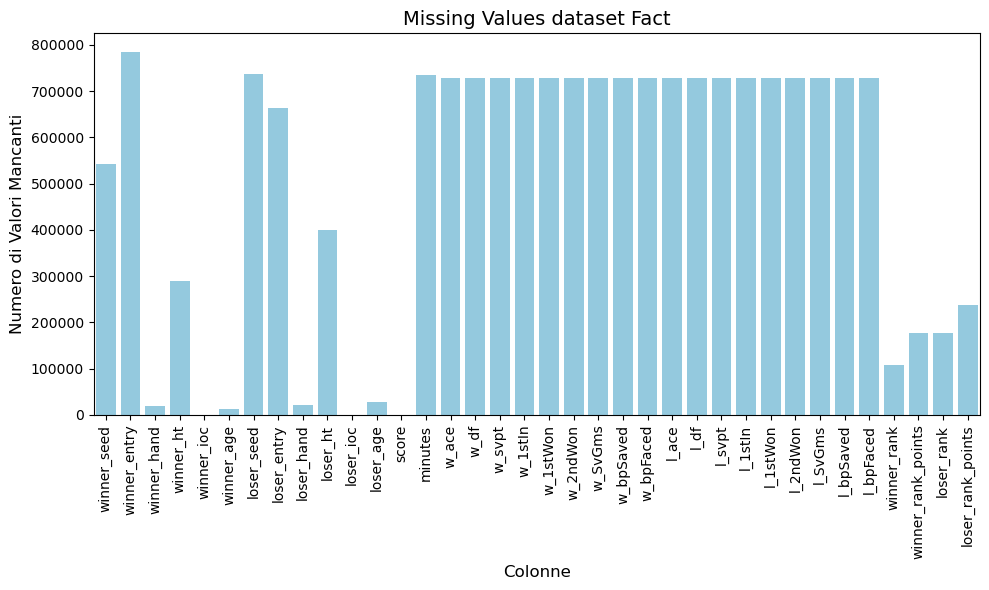

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_values = fact.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='skyblue')

plt.title('Missing Values dataset Fact', fontsize=14)
plt.xlabel('Colonne', fontsize=12)
plt.ylabel('Numero di Valori Mancanti', fontsize=12)
plt.xticks(rotation=90) 

plt.tight_layout()
plt.show()


In [37]:
missing_percent = fact.isna().mean() * 100  # Calcola la percentuale di missing values per ogni colonna
columns_over_70 = missing_percent[missing_percent > 70].index  # Seleziona le colonne con più del 70% di missing

print("Colonne con oltre il 70% di valori mancanti:")
print(columns_over_70)
print(missing_percent[missing_percent > 70])

Colonne con oltre il 70% di valori mancanti:
Index(['winner_entry', 'loser_seed', 'loser_entry', 'minutes', 'w_ace', 'w_df',
       'w_svpt', 'w_1stIn', 'w_1stWon', 'w_2ndWon', 'w_SvGms', 'w_bpSaved',
       'w_bpFaced', 'l_ace', 'l_df', 'l_svpt', 'l_1stIn', 'l_1stWon',
       'l_2ndWon', 'l_SvGms', 'l_bpSaved', 'l_bpFaced'],
      dtype='object')
winner_entry    83.408786
loser_seed      78.224476
loser_entry     70.533925
minutes         78.001782
w_ace           77.255856
w_df            77.255963
w_svpt          77.255963
w_1stIn         77.255963
w_1stWon        77.255963
w_2ndWon        77.255963
w_SvGms         77.256175
w_bpSaved       77.255963
w_bpFaced       77.255963
l_ace           77.255963
l_df            77.255856
l_svpt          77.255963
l_1stIn         77.255963
l_1stWon        77.255963
l_2ndWon        77.255963
l_SvGms         77.256175
l_bpSaved       77.255963
l_bpFaced       77.255963
dtype: float64


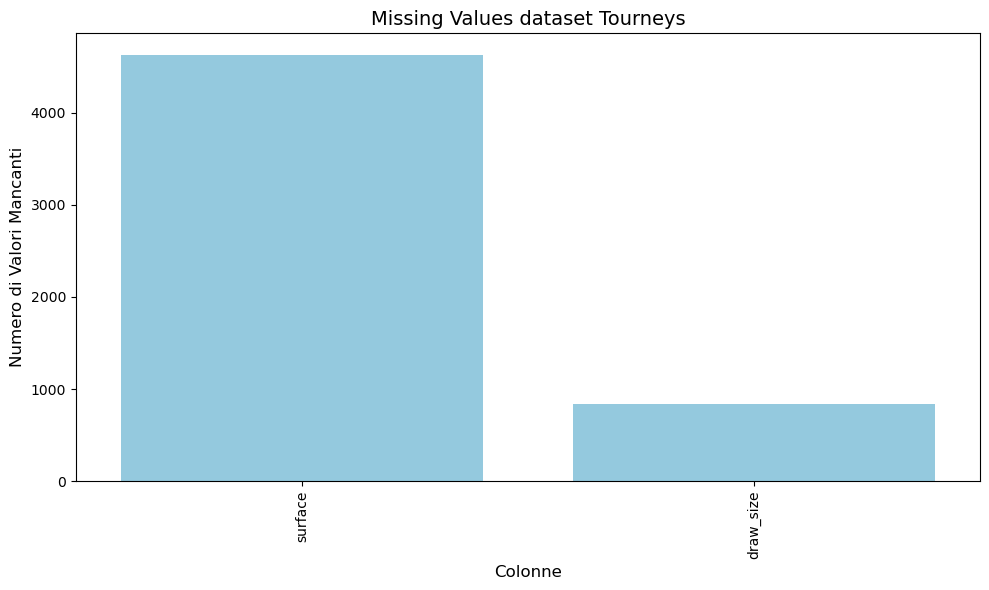

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_values = tourney.isnull().sum()

missing_values = missing_values[missing_values > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='skyblue')

plt.title('Missing Values dataset Tourneys', fontsize=14)
plt.xlabel('Colonne', fontsize=12)
plt.ylabel('Numero di Valori Mancanti', fontsize=12)
plt.xticks(rotation=90)  

plt.tight_layout()
plt.show()


draw_size --> contare per torneo gli id unici dei giocatori e riempire in questo modo sia i missing, sia 'R'

In [26]:
tourney['draw_size'].unique()

array([32.0, 16.0, 64.0, 128.0, 96.0, 4.0, 8.0, 6.0, nan, 10.0, 5.0, 9.0,
       7.0, 24.0, 48.0, 12.0, 2.0, 56.0, 28.0, '64', '48', '32', '56',
       '128', '8', '4', '96', '28', '16', '24', '12', '2', '18', 'R',
       '29', '31', '23', '30', 30, 23, 21, 22, 29, 31, 25, 17],
      dtype=object)

In [ ]:
count_r = (tourney['draw_size'] == 'R').sum()
print(f"Numero di occorrenze di 'R' in 'draw_size': {count_r}")

Numero di occorrenze di 'R' in 'draw_size': 1582


In [61]:
tourney['draw_size'].unique()

array([32.0, 16.0, 64.0, 128.0, 96.0, 4.0, 8.0, 6.0, nan, 10.0, 5.0, 9.0,
       7.0, 24.0, 48.0, 12.0, 2.0, 56.0, 28.0, '64', '48', '32', '56',
       '128', '8', '4', '96', '28', '16', '24', '12', '2', '18', 'R',
       '29', '31', '23', '30', 30, 23, 21, 22, 29, 31, 25, 17],
      dtype=object)